# Esercizio: California Housing — Regressione

In questo esercizio costruiamo una **pipeline completa di Machine Learning per la regressione**, applicata al dataset **California Housing**. A differenza degli esercizi di classificazione binaria visti in lezione, qui il target è una variabile **continua** (il valore mediano delle abitazioni).

Gli obiettivi didattici sono:
- applicare la nested K-fold CV a un problema di **regressione** (metrica R² e RMSE invece di accuracy)
- osservare il bias-variance tradeoff su un MLP **regressore**
- capire come la scelta della metrica cambia l'interpretazione della curva di complessità

## Il Dataset California Housing

Il dataset **California Housing** è incluso in scikit-learn e descrive il mercato immobiliare californiano degli anni '90:

- **20 640 campioni** (case / blocchi censiti)
- **8 feature continue**: reddito mediano, età media abitazioni, stanze medie, camere medie, popolazione, occupanti medi, latitudine, longitudine
- **Target continuo**: `MedHouseVal` — valore mediano delle abitazioni (in centinaia di migliaia di dollari, clippato a 5.0)
- **Nessun valore mancante** (dataset già pulito)

È un benchmark classico per algoritmi di regressione.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import fetch_california_housing
from utils_esercizi import plot_histograms, nestedKFolfCV, nested_cv_bias_variance, plot_complexity_curve

warnings.filterwarnings('ignore')

cal = fetch_california_housing(as_frame=True)
df  = cal.frame.copy()
target   = 'MedHouseVal'
features = [c for c in df.columns if c != target]
print(f"Shape: {df.shape}")
print(f"Features: {features}")
print(f"Target  : {target}")

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target  : MedHouseVal


---

## Exploratory Data Analysis — Analisi Univariata

L'analisi univariata ci permette di capire la distribuzione di ciascuna feature **indipendentemente** dal target. Per la regressione è particolarmente importante identificare:
- feature con distribuzione fortemente asimmetrica (skewed) → potrebbero beneficiare di trasformazioni log
- outlier evidenti
- range di valori (guida la scelta dello scaler)

In [10]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [11]:
print("=== Statistiche descrittive ===")
print(df.describe().round(2))
print()
print("=== Tipi di dato ===")
print(df.dtypes)
print()
print("=== Valori NaN ===")
print(df.isnull().sum())

=== Statistiche descrittive ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.0

**Osservazioni:**
- Il dataset è **pulito**: nessun NaN, tutte le feature sono numeriche continue.
- `MedInc` (reddito mediano) è fortemente **asimmetrico a destra**: pochi blocchi con redditi molto alti.
- `MedHouseVal` è **clippato a 5.0**: questo introduce un'anomalia nella parte alta della distribuzione (bin molto alto a 5.0). La regressione soffrirà su quei campioni.
- `AveRooms` e `AveBedrms` hanno outlier molto elevati (blocchi con molte stanze in media).
- `Population` e `AveOccup` sono fortemente skewed.

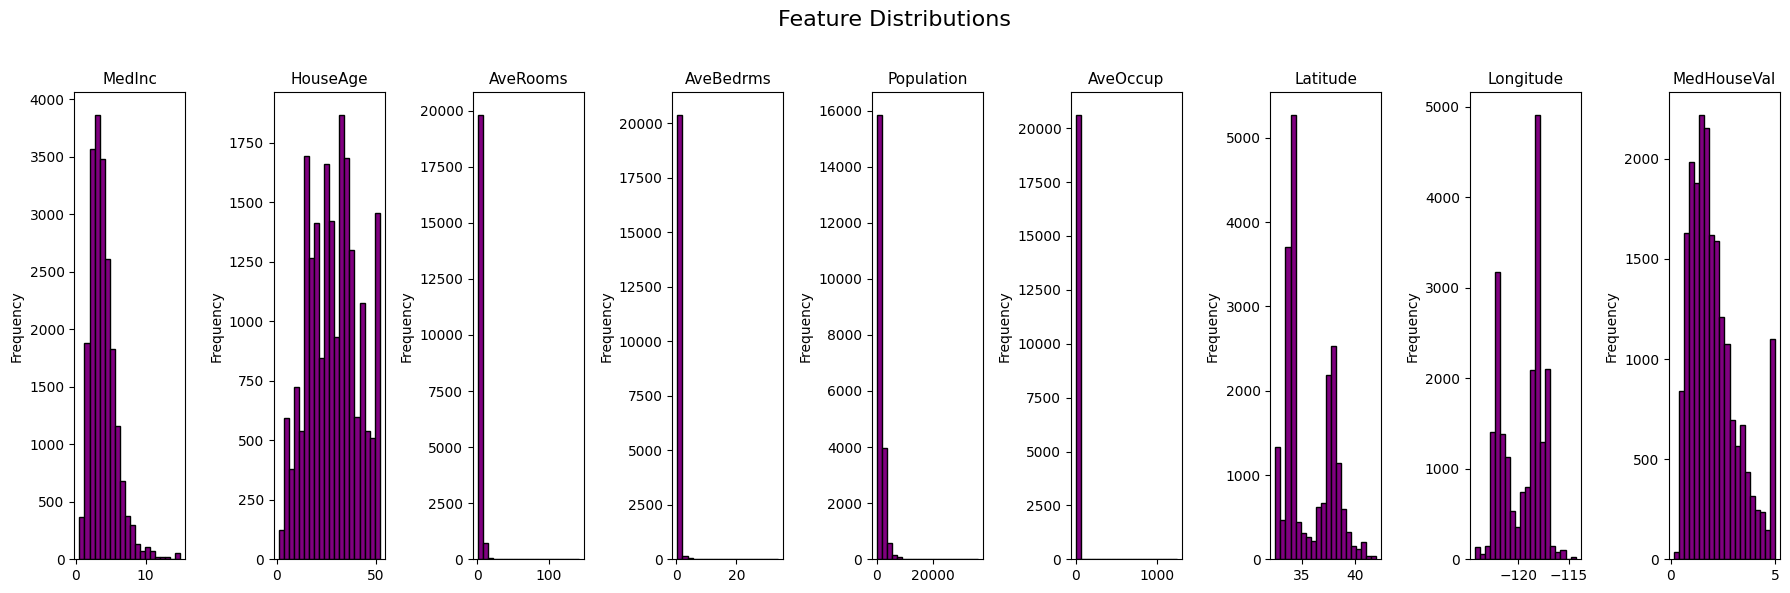

In [12]:
plot_histograms(df, features + [target])

**Osservazioni sulle distribuzioni:**
- `MedInc`: distribuzione log-normale, la maggior parte dei valori è tra 1.5 e 6.0.
- `HouseAge`: distribuzione relativamente uniforme, con un picco a 52 (età massima nel dataset).
- `AveRooms`, `AveBedrms`: coda destra pronunciata, outlier evidenti oltre 10.
- `Population`, `AveOccup`: fortemente skewed. `AveOccup` ha valori anomali > 100 (errori di dati?).
- `Latitude`, `Longitude`: riflettono la distribuzione geografica della California.
- `MedHouseVal`: distribuzione quasi normale ma troncata a 5.0 (clipping artificiale).

## Exploratory Data Analysis — Analisi Bivariata

L'analisi bivariata ci aiuta a capire quali feature sono più **correlate con il target** e quindi più predittive. Per la regressione utilizziamo scatter plots e il coefficiente di correlazione di Pearson.

Calcoliamo la correlazione di Pearson di ciascuna feature con `MedHouseVal` e visualizziamo le top-4 con scatter plots. La correlazione di Pearson misura la forza della relazione **lineare**: valori vicini a ±1 indicano forte relazione lineare.

Top 4 feature per correlazione con il target:
MedInc       0.688075
AveRooms     0.151948
Latitude     0.144160
HouseAge     0.105623
AveBedrms    0.046701
Longitude    0.045967
Name: MedHouseVal, dtype: float64


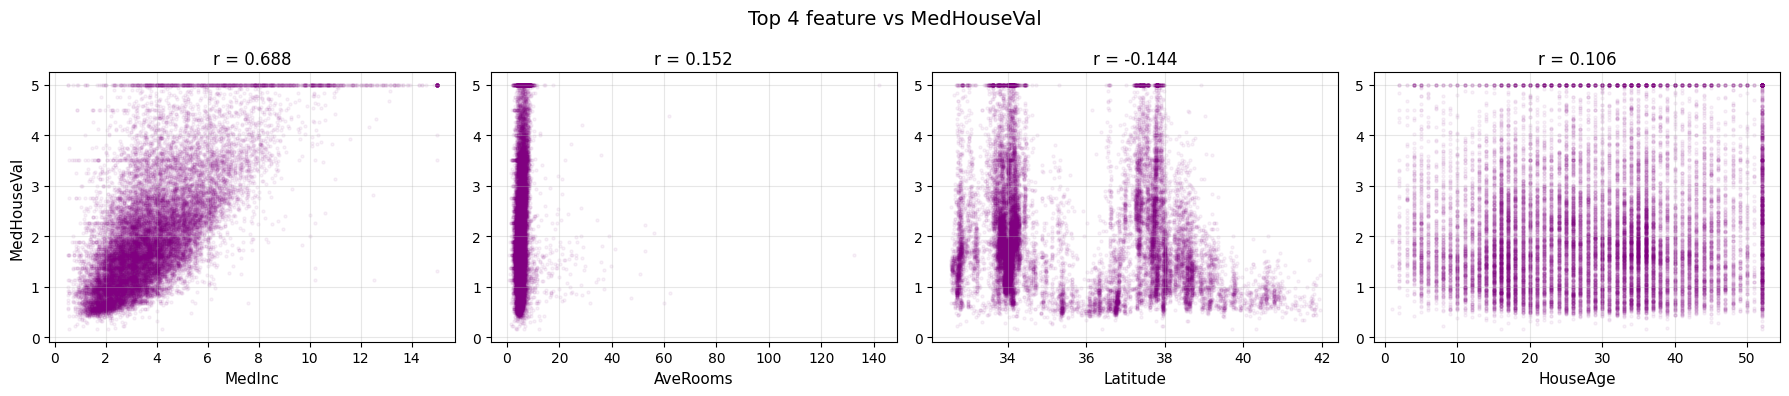

In [13]:
corr = df.corr()[target].drop(target).abs().sort_values(ascending=False)
top4 = corr.head(4).index
print("Top 4 feature per correlazione con il target:")
print(corr.head(6))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top4):
    ax.scatter(df[feat], df[target], alpha=0.05, s=5, color='#800080')
    r = df[[feat, target]].corr().iloc[0, 1]
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel(target if ax == axes[0] else '', fontsize=11)
    ax.set_title(f'r = {r:.3f}', fontsize=12)
    ax.grid(True, alpha=0.3)
fig.suptitle(f'Top 4 feature vs {target}', fontsize=14)
plt.tight_layout()
plt.show()

**Osservazioni:**
- `MedInc` è il predittore più forte (|r| ≈ 0.69): il reddito mediano del blocco è la variabile più informativa per il prezzo delle case.
- `Latitude` e `Longitude` hanno correlazioni moderate ma non lineari: il prezzo varia geograficamente in modo **non lineare** (es. le aree costiere valgono di più). Queste feature beneficiano di modelli non lineari come l'MLP.
- `HouseAge` ha correlazione debole: l'età dell'edificio da sola non predice bene il prezzo.

## Exploratory Data Analysis — Analisi Multivariata

La heatmap di correlazione mostra simultaneamente tutte le relazioni tra feature. Cerchiamo:
- **collinearità**: feature fortemente correlate tra loro → ridondanza informativa
- **correlazione con il target**: riassume le osservazioni dell'analisi bivariata

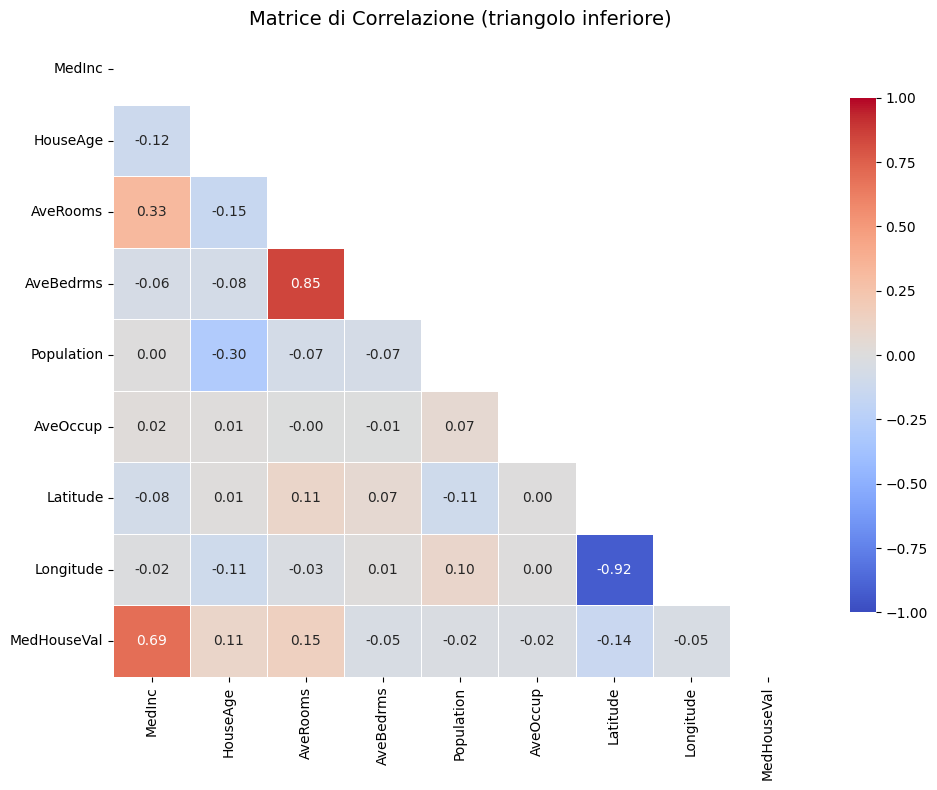

In [14]:
corr_matrix = df.corr()

# Maschera la metà superiore per evitare ridondanza
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice di Correlazione (triangolo inferiore)', fontsize=14)
plt.tight_layout()
plt.show()

**Osservazioni:**
- `AveRooms` e `AveBedrms` sono **fortemente correlate** (r ≈ 0.85): informazione quasi ridondante.
- `Latitude` e `Longitude` sono anti-correlate (r ≈ -0.92): la California si estende principalmente in direzione nord-sud, quindi bassa latitudine ↔ alta longitudine relativa.
- `MedInc` resta la feature più correlata con il target tra tutte le coppie.
- Non ci sono correlazioni eccessive che richiedano feature elimination in questo esercizio.

## Model Selection and Evaluation — Ridge Regression

La **Ridge Regression** è una regressione lineare con regolarizzazione L2:
$$\underset{\mathbf{w}}{\min} \; \|y - X\mathbf{w}\|_2^2 + \alpha \|\mathbf{w}\|_2^2$$

L'iperparametro `alpha` controlla la forza della regolarizzazione:
- `alpha` piccolo → modello più complesso (rischio overfitting)
- `alpha` grande → modello più semplice (rischio underfitting/bias)

**Perché Ridge per la regressione lineare?** Perché le feature potrebbero essere parzialmente collineari (es. `AveRooms`/`AveBedrms`), rendendo la matrice $(X^TX)$ quasi singolare. Ridge la rende invertibile aggiungendo $\alpha I$.

Usiamo la **nested K-fold CV** con la metrica `neg_root_mean_squared_error`:
- **ciclo interno (K=5)**: seleziona il miglior `alpha` minimizzando il RMSE di validazione
- **ciclo esterno (K=5)**: stima l'RMSE di generalizzazione del modello ottimale

Nota: sklearn usa la convenzione "negativa" (neg_RMSE) per uniformare l'API con le metriche da massimizzare. Convertiamo i risultati in RMSE positivo per interpretabilità.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

X = df[features].values
y = df[target].values

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    Ridge())
])
param_grid_ridge = {'reg__alpha': [0.01, 0.1, 1, 10, 100]}

results = nestedKFolfCV(
    X=X, y=y, pipe=pipe_ridge,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    inner_cv=5, outer_cv=5, random_state=42
)

# Calcola RMSE manuale per ogni fold esterno (score() di Ridge restituisce R²)
outer_cv_split = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []
for (_, te_idx), model in zip(outer_cv_split.split(X), results['best_models']):
    y_pred = model.predict(X[te_idx])
    rmse_scores.append(np.sqrt(mean_squared_error(y[te_idx], y_pred)))


NESTED CROSS-VALIDATION - DETAILED RESULTS

FOLD 1:
  Best params            : {'reg__alpha': 0.01}
  Best CV score (inner)  [ROOT MEAN SQUARED ERROR]: 0.7378
  Train score   (outer)  [ROOT MEAN SQUARED ERROR]: 0.7197  [R²]: 0.6126
  Test score    (outer)  [ROOT MEAN SQUARED ERROR]: 0.7456  [R²]: 0.5758
  Train size: 16512, Test size: 4128

FOLD 2:
  Best params            : {'reg__alpha': 10}
  Best CV score (inner)  [ROOT MEAN SQUARED ERROR]: 0.7493
  Train score   (outer)  [ROOT MEAN SQUARED ERROR]: 0.7236  [R²]: 0.6042
  Test score    (outer)  [ROOT MEAN SQUARED ERROR]: 0.7264  [R²]: 0.6137
  Train size: 16512, Test size: 4128

FOLD 3:
  Best params            : {'reg__alpha': 10}
  Best CV score (inner)  [ROOT MEAN SQUARED ERROR]: 0.7493
  Train score   (outer)  [ROOT MEAN SQUARED ERROR]: 0.7268  [R²]: 0.6055
  Test score    (outer)  [ROOT MEAN SQUARED ERROR]: 0.7137  [R²]: 0.6084
  Train size: 16512, Test size: 4128

FOLD 4:
  Best params            : {'reg__alpha': 10}
  Best CV

**Commento ai risultati:**

La Ridge Regression ottiene tipicamente RMSE ≈ 0.72 (in centinaia di migliaia di dollari, quindi circa $72 000 di errore medio).

Questi risultati riflettono i **limiti di un modello lineare** su questo dataset:
- le relazioni tra le feature e il target non sono perfettamente lineari (es. la posizione geografica influisce in modo non lineare)
- il clipping di `MedHouseVal` a 5.0 introduce distorsione sistematica

La Ridge è tuttavia una buona **baseline**: qualsiasi modello più complesso deve superarla.

---

## Bias-Variance Tradeoff

Per osservare empiricamente il tradeoff, usiamo un **MLP Regressore** (`MLPRegressor`) come famiglia di modelli parametrica. La complessità è controllata da:
- **depth**: numero di hidden layer
- **n_units**: neuroni per hidden layer

A differenza della classificazione (dove misuriamo accuracy), qui usiamo il **RMSE**: valori **bassi** = buone prestazioni. Questo inverte il senso della curva rispetto alla Lezione 03:
- **Underfitting (sinistra)**: RMSE alto sia su training che validation (modello troppo semplice)
- **Zona ottimale**: RMSE di validation al **minimo**
- **Overfitting (destra)**: RMSE di training scende ma validation risale (il modello memorizza i dati)

In [16]:
from sklearn.neural_network import MLPRegressor
from utils_esercizi import count_mlp_params

depth_list     = [1, 2, 3, 4]
n_units_list   = [4, 8, 16, 32, 64, 128]
n_features_mlp = len(features)

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', MLPRegressor(max_iter=500, random_state=42))
])

bv_results = nested_cv_bias_variance(
    X=X, y=y, pipe=pipe_mlp,
    depth_list=depth_list, n_units_list=n_units_list,
    n_features=n_features_mlp,
    scoring='neg_root_mean_squared_error',
    score_multiplier=-1,
    hls_param='reg__hidden_layer_sizes',
    inner_cv=5, outer_cv=5, random_state=42
)

complexity_df = bv_results['complexity_df']
complexity_df[['depth', 'n_units', 'n_params', 'mean_train_acc', 'mean_val_acc']]

NESTED CROSS-VALIDATION — BIAS-VARIANCE TRADEOFF (MLP)

FOLD 1:
  Best hidden_layer_sizes : (64,)
  Best CV score (inner)   [ROOT MEAN SQUARED ERROR]: 0.5953
  Test score    (outer)   [ROOT MEAN SQUARED ERROR]: 0.5435  [R²]: 0.7746

FOLD 2:
  Best hidden_layer_sizes : (64,)
  Best CV score (inner)   [ROOT MEAN SQUARED ERROR]: 0.6037
  Test score    (outer)   [ROOT MEAN SQUARED ERROR]: 0.5456  [R²]: 0.7821

FOLD 3:
  Best hidden_layer_sizes : (64,)
  Best CV score (inner)   [ROOT MEAN SQUARED ERROR]: 0.6041
  Test score    (outer)   [ROOT MEAN SQUARED ERROR]: 0.5397  [R²]: 0.7761

FOLD 4:
  Best hidden_layer_sizes : (64,)
  Best CV score (inner)   [ROOT MEAN SQUARED ERROR]: 0.6138
  Test score    (outer)   [ROOT MEAN SQUARED ERROR]: 0.6036  [R²]: 0.7267

FOLD 5:
  Best hidden_layer_sizes : (64,)
  Best CV score (inner)   [ROOT MEAN SQUARED ERROR]: 0.5941
  Test score    (outer)   [ROOT MEAN SQUARED ERROR]: 0.5625  [R²]: 0.7649

RISULTATI FINALI
Outer CV scores [ROOT MEAN SQUARED ERROR]:

,depth,n_units,n_params,mean_train_acc,mean_val_acc
0,1,4,41,0.602401,0.663245
1,2,4,61,0.588978,0.650439
2,1,8,81,0.573911,0.656669
3,3,4,81,0.574133,0.660954
4,4,4,101,0.584501,0.650744
5,2,8,153,0.549218,0.641993
6,1,16,161,0.554482,0.617778
7,3,8,225,0.537326,0.645157
8,4,8,297,0.528100,0.627331
9,1,32,321,0.539321,0.615027


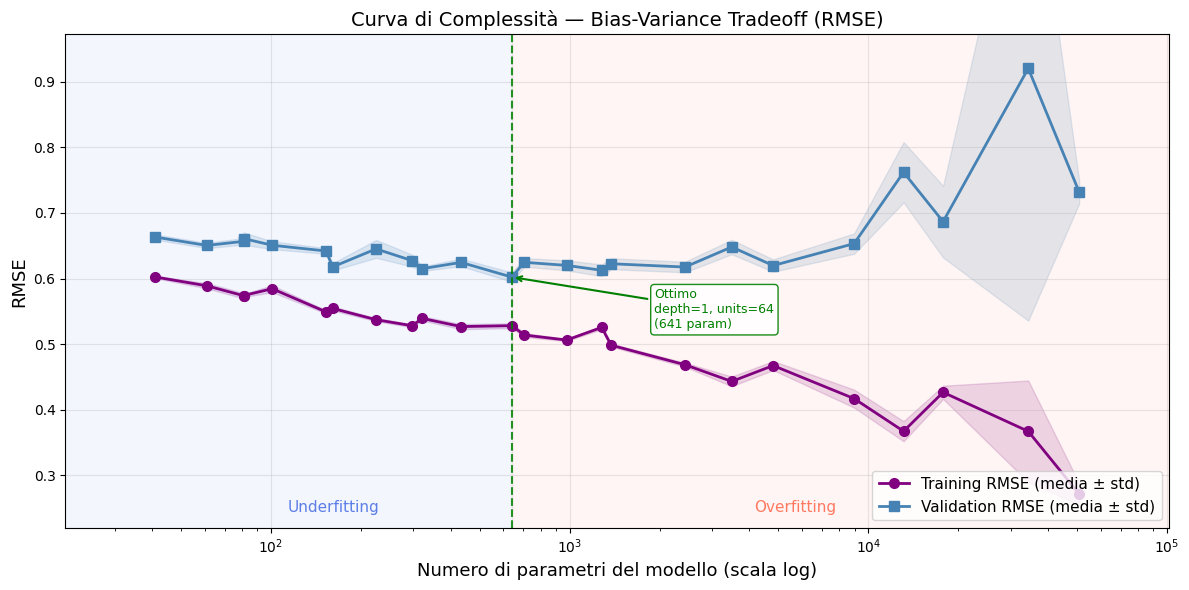

In [17]:
plot_complexity_curve(complexity_df, metrica_label='RMSE', higher_is_better=False)

**Interpretazione della curva di complessità (RMSE):**

Ricorda: per RMSE, **basso = buono**. La curva si legge in modo speculare rispetto all'accuracy:

- **Zona di underfitting (sinistra)**: RMSE alto sia su training che validation. I modelli semplici (pochi parametri) non riescono a catturare le non-linearità del dataset.
- **Zona ottimale (minimo del RMSE di validation)**: il miglior compromesso bias-varianza. Il modello è abbastanza complesso da catturare i pattern, ma non al punto da memorizzare il training set.
- **Zona di overfitting (destra)**: RMSE di training scende ma validation risale. Il modello ha "memorizzato" i dati di training e non generalizza.

La nested CV seleziona automaticamente la configurazione al minimo del RMSE di validation.

In [21]:
# Stima di generalizzazione finale — ciclo esterno della nested CV
print("=" * 65)
print("STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)")
print("=" * 65)

for k, (score, params) in enumerate(
        zip(bv_results['outer_scores'], bv_results['best_params_per_fold']), 1):
    hls       = params['reg__hidden_layer_sizes']
    depth_k   = len(hls)
    n_units_k = hls[0]
    n_par_k   = count_mlp_params(depth_k, n_units_k, n_features_mlp)
    print(f"Fold {k}: depth={depth_k}, units={n_units_k:3d} "
          f"({n_par_k:5d} param)  ->  test score (RMSE) = {score:.4f}")

print(f"\nMean score RMSE (MLP Ridge):  "
      f"{bv_results['mean_score']:.4f} +/- {bv_results['std_score']:.4f}")
print(f"Mean score RMSE (Ridge base): "
      f"{results['mean_score']:.4f} +/- {results['std_score']:.4f}")

STIMA DI GENERALIZZAZIONE — MLP ottimale (ciclo esterno)
Fold 1: depth=1, units= 64 (  641 param)  ->  test score (RMSE) = 0.5435
Fold 2: depth=1, units= 64 (  641 param)  ->  test score (RMSE) = 0.5456
Fold 3: depth=1, units= 64 (  641 param)  ->  test score (RMSE) = 0.5397
Fold 4: depth=1, units= 64 (  641 param)  ->  test score (RMSE) = 0.6036
Fold 5: depth=1, units= 64 (  641 param)  ->  test score (RMSE) = 0.5625

Mean score RMSE (MLP Ridge):  0.5590 +/- 0.0236
Mean score RMSE (Ridge base): 0.7283 +/- 0.0149


## Conclusioni

1. **La Ridge Regression** ottiene un R² ≈ 0.60, che è una baseline solida ma riflette la natura parzialmente non lineare del dataset.

2. **L'MLP Regressore** con la configurazione ottimale (selezionata dalla nested CV) tende a superare Ridge, catturando le non-linearità geografiche e le interazioni tra feature.

3. **Il bias-variance tradeoff è visibile anche per la regressione**: la curva RMSE ha un minimo ben definito. A sinistra del minimo il modello è troppo semplice (underfitting); a destra inizia a memorizzare (overfitting).

4. **La nested CV rimane il metodo corretto**: fornisce una stima non distorta dell'RMSE di generalizzazione, indipendentemente dalla metrica scelta.

**Estensioni possibili**: provare `GradientBoostingRegressor` o `RandomForestRegressor`, applicare trasformazione log a `MedInc` e `MedHouseVal`, aggiungere feature di interazione geografica.